# 8. Graph Attention Network Model

This notebook trains a Graph Attention Network (GAT) on the prepared Elliptic Bitcoin transaction graph. Similar to the GCN model, the full transaction graph is used for message passing, while supervised learning is applied only to labeled nodes through the train, validation, and test masks.

The GAT model differs from GCN because it learns attention weights over neighboring nodes. This allows the model to assign different importance to different transaction neighbors during message passing.

In [1]:
from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
from torch import nn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

from torch_geometric.data import Data
from torch_geometric.nn import GATConv

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 1000)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Libraries imported successfully.
PyTorch version: 2.13.0+cpu
CUDA available: False


## 8.1 Load Prepared Graph Data

The graph data prepared earlier is loaded from the saved NumPy compressed file. This includes the node feature matrix, labels, edge index, and train-validation-test masks.

In [2]:
PROJECT_DIR = Path.cwd().resolve()

if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

GRAPH_DIR = PROJECT_DIR / "data" / "processed" / "graph_data"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = PROJECT_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

graph_path = GRAPH_DIR / "elliptic_graph_data.npz"

graph_npz = np.load(graph_path)

X_all = graph_npz["x"]
y_all = graph_npz["y"]
edge_index_undirected = graph_npz["edge_index_undirected"]
train_mask_np = graph_npz["train_mask"]
val_mask_np = graph_npz["val_mask"]
test_mask_np = graph_npz["test_mask"]

print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)
print("edge_index_undirected shape:", edge_index_undirected.shape)
print("Train mask:", train_mask_np.sum())
print("Validation mask:", val_mask_np.sum())
print("Test mask:", test_mask_np.sum())

X_all shape: (203769, 165)
y_all shape: (203769,)
edge_index_undirected shape: (2, 468710)
Train mask: 27938
Validation mask: 9313
Test mask: 9313


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

x = torch.tensor(X_all, dtype=torch.float32)
y = torch.tensor(y_all, dtype=torch.long)
edge_index = torch.tensor(edge_index_undirected, dtype=torch.long)

train_mask = torch.tensor(train_mask_np, dtype=torch.bool)
val_mask = torch.tensor(val_mask_np, dtype=torch.bool)
test_mask = torch.tensor(test_mask_np, dtype=torch.bool)

data = Data(
    x=x,
    edge_index=edge_index,
    y=y,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask
)

data = data.to(device)

print(data)
print("Number of node features:", data.num_node_features)
print("Number of classes:", 2)

Using device: cpu
Data(x=[203769, 165], edge_index=[2, 468710], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])
Number of node features: 165
Number of classes: 2


## 8.2 Define GAT Model

The GAT model uses graph attention layers. The first layer uses multiple attention heads to learn neighborhood-aware node representations. The second layer maps the learned representation to two output classes: licit and illicit.

In [4]:
class GATModel(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim=16,
        output_dim=2,
        heads=4,
        dropout=0.5
    ):
        super().__init__()

        self.gat1 = GATConv(
            in_channels=input_dim,
            out_channels=hidden_dim,
            heads=heads,
            dropout=dropout,
            concat=True
        )

        self.gat2 = GATConv(
            in_channels=hidden_dim * heads,
            out_channels=output_dim,
            heads=1,
            dropout=dropout,
            concat=False
        )

        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat2(x, edge_index)
        return x


input_dim = data.num_node_features

gat_model = GATModel(
    input_dim=input_dim,
    hidden_dim=16,
    output_dim=2,
    heads=4,
    dropout=0.5
).to(device)

print(gat_model)

GATModel(
  (gat1): GATConv(165, 16, heads=4)
  (gat2): GATConv(64, 2, heads=1)
)


## 8.3 Handle Class Imbalance

The training labels are imbalanced, so class weights are calculated from the training mask and applied to the cross-entropy loss function.

In [5]:
train_labels = data.y[data.train_mask]

num_licit_train = (train_labels == 0).sum().item()
num_illicit_train = (train_labels == 1).sum().item()

print("Train licit count:", num_licit_train)
print("Train illicit count:", num_illicit_train)

total_train = num_licit_train + num_illicit_train

weight_licit = total_train / (2 * num_licit_train)
weight_illicit = total_train / (2 * num_illicit_train)

class_weights = torch.tensor(
    [weight_licit, weight_illicit],
    dtype=torch.float32
).to(device)

print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(
    gat_model.parameters(),
    lr=0.005,
    weight_decay=5e-4
)

Train licit count: 25211
Train illicit count: 2727
Class weights: tensor([0.5541, 5.1225])


## 8.4 Evaluation Function

The evaluation function calculates the same metrics used for previous models so that GAT can be compared fairly with Logistic Regression, Random Forest, XGBoost, and GCN.

In [6]:
def evaluate_model(model, data, mask):
    model.eval()

    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(dim=1)

    y_true = data.y[mask].detach().cpu().numpy()
    y_pred = preds[mask].detach().cpu().numpy()
    y_proba = probs[mask].detach().cpu().numpy()

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba)
    }

    cm = confusion_matrix(y_true, y_pred)

    return metrics, cm, y_true, y_pred, y_proba

## 8.5 Train the GAT Model

The GAT model is trained using the training mask. Validation PR-AUC is monitored after each epoch, and the best model is saved based on validation PR-AUC.

In [7]:
num_epochs = 80
best_val_pr_auc = -1
best_epoch = 0
best_model_path = MODELS_DIR / "gat_best_model.pt"

history = []

start_time = time.time()

for epoch in range(1, num_epochs + 1):
    gat_model.train()
    optimizer.zero_grad()

    logits = gat_model(data.x, data.edge_index)

    loss = criterion(
        logits[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()
    optimizer.step()

    train_metrics, _, _, _, _ = evaluate_model(gat_model, data, data.train_mask)
    val_metrics, _, _, _, _ = evaluate_model(gat_model, data, data.val_mask)

    history.append({
        "epoch": epoch,
        "loss": loss.item(),
        "train_accuracy": train_metrics["accuracy"],
        "train_precision": train_metrics["precision"],
        "train_recall": train_metrics["recall"],
        "train_f1": train_metrics["f1"],
        "train_roc_auc": train_metrics["roc_auc"],
        "train_pr_auc": train_metrics["pr_auc"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"]
    })

    if val_metrics["pr_auc"] > best_val_pr_auc:
        best_val_pr_auc = val_metrics["pr_auc"]
        best_epoch = epoch
        torch.save(gat_model.state_dict(), best_model_path)

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {loss.item():.4f} | "
            f"Train F1: {train_metrics['f1']:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f} | "
            f"Val PR-AUC: {val_metrics['pr_auc']:.4f}"
        )

end_time = time.time()

print("\nTraining completed.")
print("Best epoch:", best_epoch)
print("Best validation PR-AUC:", round(best_val_pr_auc, 4))
print("Training time in seconds:", round(end_time - start_time, 2))

Epoch 001 | Loss: 1.8142 | Train F1: 0.2676 | Val F1: 0.2653 | Val PR-AUC: 0.3169
Epoch 010 | Loss: 0.6971 | Train F1: 0.4047 | Val F1: 0.3948 | Val PR-AUC: 0.6085
Epoch 020 | Loss: 0.5804 | Train F1: 0.3881 | Val F1: 0.3830 | Val PR-AUC: 0.6997
Epoch 030 | Loss: 0.5214 | Train F1: 0.4004 | Val F1: 0.3991 | Val PR-AUC: 0.7573
Epoch 040 | Loss: 0.4986 | Train F1: 0.4018 | Val F1: 0.3952 | Val PR-AUC: 0.7664
Epoch 050 | Loss: 0.4831 | Train F1: 0.4231 | Val F1: 0.4218 | Val PR-AUC: 0.7728
Epoch 060 | Loss: 0.4838 | Train F1: 0.4304 | Val F1: 0.4252 | Val PR-AUC: 0.7910
Epoch 070 | Loss: 1.4891 | Train F1: 0.4204 | Val F1: 0.4151 | Val PR-AUC: 0.7947
Epoch 080 | Loss: 0.4599 | Train F1: 0.4393 | Val F1: 0.4367 | Val PR-AUC: 0.8036

Training completed.
Best epoch: 80
Best validation PR-AUC: 0.8036
Training time in seconds: 177.3


In [8]:
history_df = pd.DataFrame(history)

gat_history_path = RESULTS_DIR / "gat_training_history.csv"

history_df.to_csv(gat_history_path, index=False)

display(history_df.tail())

print("GAT training history saved to:")
print(gat_history_path.relative_to(PROJECT_DIR))

,epoch,loss,train_accuracy,train_precision,train_recall,train_f1,train_roc_auc,train_pr_auc,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,val_pr_auc
75,76,0.460092,0.765839,0.289761,0.964063,0.445593,0.962187,0.807649,0.763556,0.286563,0.954895,0.440833,0.958154,0.800797
76,77,0.469184,0.766841,0.290519,0.962963,0.446371,0.962260,0.808106,0.766563,0.289237,0.954895,0.443990,0.958237,0.801502
77,78,0.466857,0.764657,0.288711,0.964063,0.444351,0.962417,0.808246,0.764845,0.287844,0.955996,0.442464,0.958464,0.802331
78,79,0.465128,0.761973,0.286538,0.965530,0.441927,0.962617,0.808138,0.761301,0.285013,0.958196,0.439344,0.958710,0.802929
79,80,0.459884,0.758966,0.284175,0.967363,0.439301,0.962831,0.808144,0.758402,0.282658,0.959296,0.436655,0.958988,0.803607


GAT training history saved to:
results\gat_training_history.csv


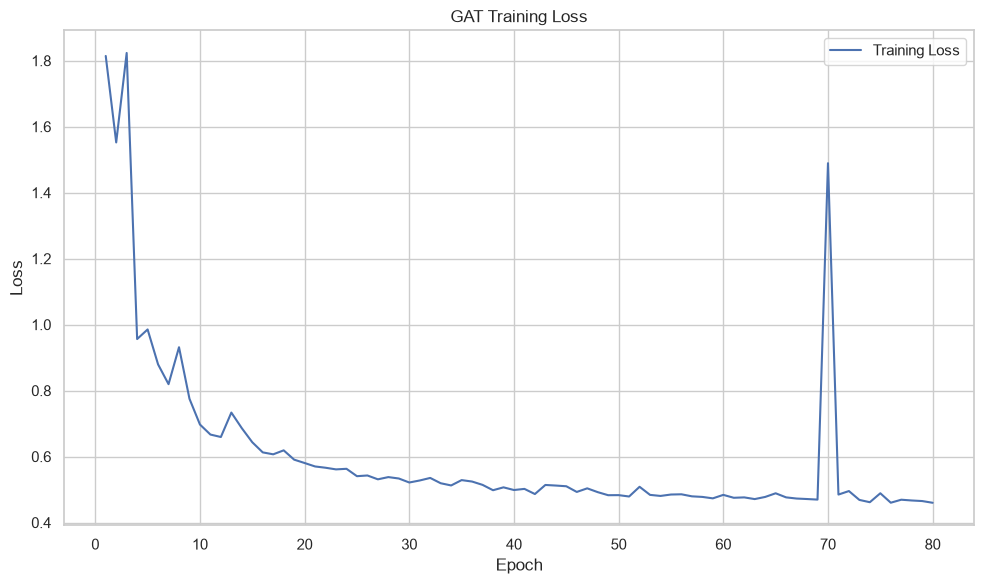

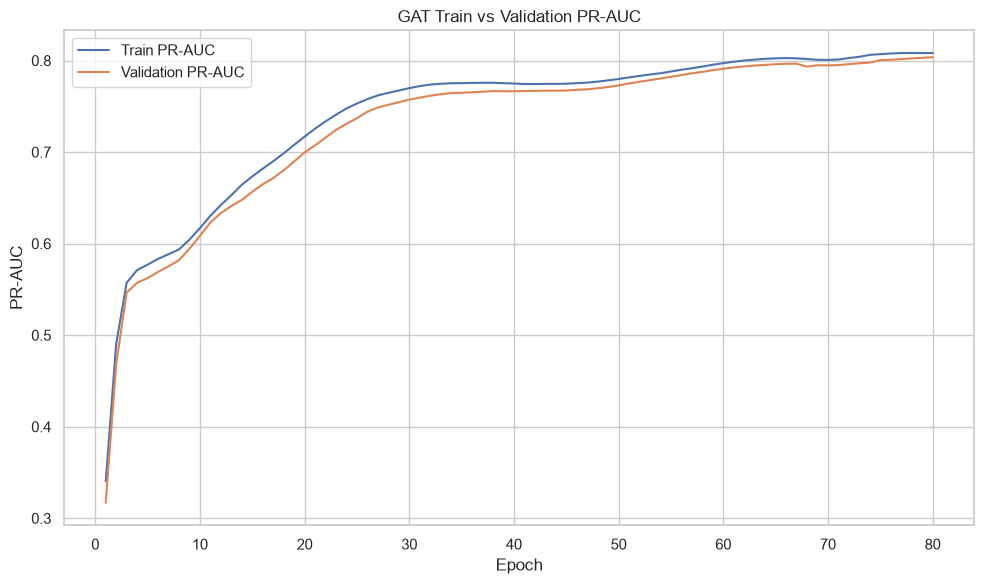

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(history_df["epoch"], history_df["loss"], label="Training Loss")
plt.title("GAT Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gat_training_loss.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history_df["epoch"], history_df["train_pr_auc"], label="Train PR-AUC")
plt.plot(history_df["epoch"], history_df["val_pr_auc"], label="Validation PR-AUC")
plt.title("GAT Train vs Validation PR-AUC")
plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gat_train_val_pr_auc.png", dpi=300)
plt.show()

## 8.6 Evaluate the Best GAT Model

The best GAT model is reloaded and evaluated on the validation and test sets.

In [10]:
best_gat_model = GATModel(
    input_dim=input_dim,
    hidden_dim=16,
    output_dim=2,
    heads=4,
    dropout=0.5
).to(device)

best_gat_model.load_state_dict(
    torch.load(best_model_path, map_location=device)
)

print("Best GAT model loaded from:")
print(best_model_path.relative_to(PROJECT_DIR))

Best GAT model loaded from:
models\gat_best_model.pt


In [11]:
gat_val_metrics, gat_val_cm, y_val_true, y_val_pred, y_val_proba = evaluate_model(
    best_gat_model,
    data,
    data.val_mask
)

gat_test_metrics, gat_test_cm, y_test_true, y_test_pred, y_test_proba = evaluate_model(
    best_gat_model,
    data,
    data.test_mask
)

print("GAT Validation Metrics:")
for key, value in gat_val_metrics.items():
    print(f"{key}: {value:.4f}")

print("\nGAT Test Metrics:")
for key, value in gat_test_metrics.items():
    print(f"{key}: {value:.4f}")

print("\nGAT Test Classification Report:")
print(classification_report(y_test_true, y_test_pred, digits=4))

GAT Validation Metrics:
accuracy: 0.7584
precision: 0.2827
recall: 0.9593
f1: 0.4367
roc_auc: 0.9590
pr_auc: 0.8036

GAT Test Metrics:
accuracy: 0.7601
precision: 0.2834
recall: 0.9538
f1: 0.4370
roc_auc: 0.9589
pr_auc: 0.8035

GAT Test Classification Report:
              precision    recall  f1-score   support

           0     0.9933    0.7392    0.8476      8404
           1     0.2834    0.9538    0.4370       909

    accuracy                         0.7601      9313
   macro avg     0.6384    0.8465    0.6423      9313
weighted avg     0.9240    0.7601    0.8075      9313



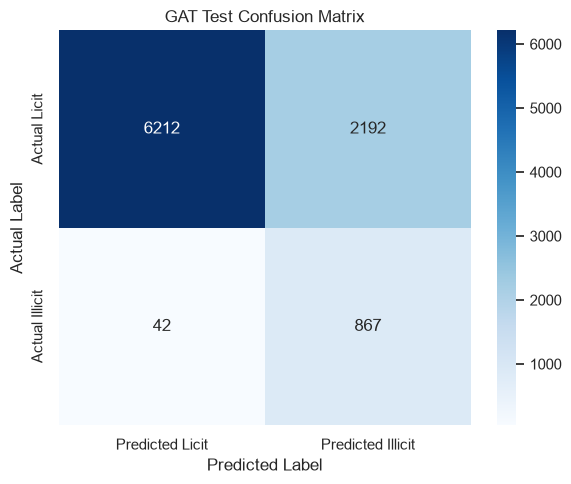

array([[6212, 2192],
       [  42,  867]])

In [12]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    gat_test_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Licit", "Predicted Illicit"],
    yticklabels=["Actual Licit", "Actual Illicit"]
)
plt.title("GAT Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gat_test_confusion_matrix.png", dpi=300)
plt.show()

gat_test_cm

In [13]:
gat_results = {
    "best_epoch": int(best_epoch),
    "best_validation_pr_auc": float(best_val_pr_auc),
    "validation_metrics": {k: float(v) for k, v in gat_val_metrics.items()},
    "test_metrics": {k: float(v) for k, v in gat_test_metrics.items()},
    "test_confusion_matrix": gat_test_cm.tolist()
}

gat_metrics_path = RESULTS_DIR / "gat_metrics_summary.json"
gat_test_results_path = RESULTS_DIR / "gat_test_results.csv"

with open(gat_metrics_path, "w") as f:
    json.dump(gat_results, f, indent=4)

pd.DataFrame([{
    "model": "GAT",
    "accuracy": gat_test_metrics["accuracy"],
    "precision": gat_test_metrics["precision"],
    "recall": gat_test_metrics["recall"],
    "f1": gat_test_metrics["f1"],
    "roc_auc": gat_test_metrics["roc_auc"],
    "pr_auc": gat_test_metrics["pr_auc"]
}]).to_csv(
    gat_test_results_path,
    index=False
)

print("GAT results saved.")
print(gat_metrics_path.relative_to(PROJECT_DIR))
print(gat_test_results_path.relative_to(PROJECT_DIR))

GAT results saved.
results\gat_metrics_summary.json
results\gat_test_results.csv


## 8.7 Threshold Tuning for GAT

As with the GCN model, threshold tuning is performed using the validation set. The threshold that maximizes validation F1-score is selected and then applied to the test set.

In [14]:
precisions, recalls, thresholds = precision_recall_curve(y_val_true, y_val_proba)

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best validation threshold based on F1:", round(best_threshold, 4))
print("Validation precision at best threshold:", round(precisions[best_idx], 4))
print("Validation recall at best threshold:", round(recalls[best_idx], 4))
print("Validation F1 at best threshold:", round(f1_scores[best_idx], 4))

Best validation threshold based on F1: 0.7944
Validation precision at best threshold: 0.747
Validation recall at best threshold: 0.7503
Validation F1 at best threshold: 0.7486


In [15]:
gat_test_pred_tuned = (y_test_proba >= best_threshold).astype(int)

gat_test_metrics_tuned = {
    "accuracy": accuracy_score(y_test_true, gat_test_pred_tuned),
    "precision": precision_score(y_test_true, gat_test_pred_tuned, zero_division=0),
    "recall": recall_score(y_test_true, gat_test_pred_tuned, zero_division=0),
    "f1": f1_score(y_test_true, gat_test_pred_tuned, zero_division=0),
    "roc_auc": roc_auc_score(y_test_true, y_test_proba),
    "pr_auc": average_precision_score(y_test_true, y_test_proba)
}

gat_test_cm_tuned = confusion_matrix(y_test_true, gat_test_pred_tuned)

print("GAT Tuned-Threshold Test Metrics:")
for key, value in gat_test_metrics_tuned.items():
    print(f"{key}: {value:.4f}")

print("\nGAT Tuned-Threshold Test Classification Report:")
print(classification_report(y_test_true, gat_test_pred_tuned, digits=4))

print("\nTuned-threshold confusion matrix:")
print(gat_test_cm_tuned)

GAT Tuned-Threshold Test Metrics:
accuracy: 0.9508
precision: 0.7531
recall: 0.7382
f1: 0.7456
roc_auc: 0.9589
pr_auc: 0.8035

GAT Tuned-Threshold Test Classification Report:
              precision    recall  f1-score   support

           0     0.9717    0.9738    0.9728      8404
           1     0.7531    0.7382    0.7456       909

    accuracy                         0.9508      9313
   macro avg     0.8624    0.8560    0.8592      9313
weighted avg     0.9504    0.9508    0.9506      9313


Tuned-threshold confusion matrix:
[[8184  220]
 [ 238  671]]


In [16]:
gat_tuned_results = {
    "selected_threshold": float(best_threshold),
    "test_metrics_tuned_threshold": {k: float(v) for k, v in gat_test_metrics_tuned.items()},
    "test_confusion_matrix_tuned_threshold": gat_test_cm_tuned.tolist()
}

with open(RESULTS_DIR / "gat_tuned_threshold_results.json", "w") as f:
    json.dump(gat_tuned_results, f, indent=4)

pd.DataFrame([{
    "model": "GAT_tuned_threshold",
    "threshold": best_threshold,
    "accuracy": gat_test_metrics_tuned["accuracy"],
    "precision": gat_test_metrics_tuned["precision"],
    "recall": gat_test_metrics_tuned["recall"],
    "f1": gat_test_metrics_tuned["f1"],
    "roc_auc": gat_test_metrics_tuned["roc_auc"],
    "pr_auc": gat_test_metrics_tuned["pr_auc"]
}]).to_csv(
    RESULTS_DIR / "gat_tuned_threshold_test_results.csv",
    index=False
)

print("Tuned-threshold GAT results saved.")

Tuned-threshold GAT results saved.


## 8.8 GAT Model Summary

This notebook trained and evaluated a Graph Attention Network on the Elliptic transaction graph. The GAT model used attention-based message passing to learn node representations from transaction features and graph connectivity. The model was evaluated using the same train-validation-test masks and metrics used for the GCN model. Threshold tuning was also applied to examine whether the balance between precision and recall could be improved.